## [1] 로보플로우 데이터 다운로드
- https://public.roboflow.com/object-detection/vehicles-openimages/1
- COCO 선택
- 5개의 클래스(차량)

In [33]:
A
!curl -L "https://public.roboflow.com/ds/z4XGsflSZo?key=Y3qTcc6jXS" > roboflow.zip
!mkdir -p object
!unzip roboflow.zip -d object
!rm roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   893  100   893    0     0   1536      0 --:--:-- --:--:-- --:--:--  1534
100 38.9M  100 38.9M    0     0   9.9M      0  0:00:03  0:00:03 --:--:-- 16.4M
Archive:  roboflow.zip
 extracting: object/README.dataset.txt  
replace object/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
 extracting: object/README.roboflow.txt  
 extracting: object/test/00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg  
 extracting: object/test/00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg  
 extracting: object/test/00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg  
 extracting: object/test/00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg  
 extracting: object/test/08c8b73e0c2e296e_jpg.rf.7IkYAamjZhnwsoXSrwKt.jpg  
 extracting: object/test/08c8b73e0c2e296e_jpg.rf.effa65856584463c08848031cab357b9.jpg  
 extractin

In [34]:
import json

json_path = "/content/object/train/_annotations.coco.json"

with open(json_path, 'r', encoding='utf-8') as f:
    coco = json.load(f)
print("키 목록:", coco.keys())


키 목록: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [35]:
from google.colab import files
files.download("/content/object/train/_annotations.coco.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ image_id = 384

✔ Annotation 목록:
{'category_id': 5, 'category_name': 'Truck', 'bbox': [190, 286, 78.5, 76]}
{'category_id': 5, 'category_name': 'Truck', 'bbox': [8, 15, 50, 62.5]}
{'category_id': 5, 'category_name': 'Truck', 'bbox': [50, 126, 57.5, 62]}
{'category_id': 5, 'category_name': 'Truck', 'bbox': [92, 196, 79, 88.5]}
{'category_id': 5, 'category_name': 'Truck', 'bbox': [248, 152, 75, 86]}
{'category_id': 5, 'category_name': 'Truck', 'bbox': [271, 0, 132, 202]}

✔ 박스 시각화 결과


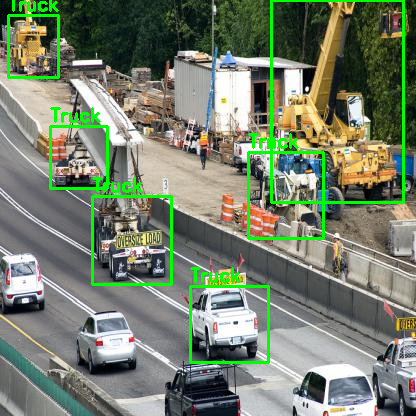

In [40]:
import json
import cv2
import os
from google.colab.patches import cv2_imshow

# -----------------------------
# 1) 경로 설정
# -----------------------------
json_path = "/content/object/train/_annotations.coco.json"
img_dir   = "/content/object/train/"

# 대상 이미지
target_image_file = "068868f40fb6dbec_jpg.rf.TuNx4cAV28rilGbgRwVh.jpg"
target_image_path = os.path.join(img_dir, target_image_file)

# -----------------------------
# 2) COCO JSON 로드
# -----------------------------
with open(json_path, "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

# 카테고리 id -> 이름 맵
cat_map = {c["id"]: c["name"] for c in categories}

# -----------------------------
# 3) file_name 으로 image_id 찾기
# -----------------------------
image_id = None
for img in images:
    if img["file_name"] == target_image_file:
        image_id = img["id"]
        break

if image_id is None:
    print("⚠ 해당 file_name을 JSON에서 찾지 못했습니다:", target_image_file)
else:
    print("✔ image_id =", image_id)

# -----------------------------
# 4) 해당 이미지의 annotation 모두 찾기
# -----------------------------
target_annos = [a for a in annotations if a["image_id"] == image_id]

print("\n✔ Annotation 목록:")
for ann in target_annos:
    print({
        "category_id": ann["category_id"],
        "category_name": cat_map.get(ann["category_id"], "unknown"),
        "bbox": ann["bbox"]
    })

# -----------------------------
# 5) 이미지 불러와서 박스 그리기
# -----------------------------
img = cv2.imread(target_image_path)
if img is None:
    print("이미지를 불러올 수 없음:", target_image_path)
else:
    for ann in target_annos:
        x, y, w, h = ann["bbox"]
        x2 = int(x + w)
        y2 = int(y + h)

        # 박스
        cv2.rectangle(img, (int(x), int(y)), (x2, y2), (0,255,0), 2)

        # 클래스명
        cls_name = cat_map.get(ann["category_id"], "unknown")
        cv2.putText(img, cls_name, (int(x), int(y)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    print("\n✔ 박스 시각화 결과")
    cv2_imshow(img)


In [45]:
import json

json_path = "/content/object/train/_annotations.coco.json"

with open(json_path, "r") as f:
    coco = json.load(f)

images = coco["images"]

target_file = "068868f40fb6dbec_jpg.rf.TuNx4cAV28rilGbgRwVh.jpg"

image_id = None
for img in images:
    if img["file_name"] == target_file:
        image_id = img["id"]
        print("✔ Found image id:", image_id)
        print("Full image entry:", img)
        break

if image_id is None:
    print("⚠ 이미지 파일명과 일치하는 entry를 찾지 못했습니다:", target_file)


✔ Found image id: 384
Full image entry: {'id': 384, 'license': 1, 'file_name': '068868f40fb6dbec_jpg.rf.TuNx4cAV28rilGbgRwVh.jpg', 'height': 416, 'width': 416, 'date_captured': '2021-06-18T09:03:16+00:00'}


✔ image_id = 384

✔ 해당 이미지의 Annotation (원본 그대로 출력)

{
    "id": 725,
    "image_id": 384,
    "category_id": 5,
    "bbox": [
        190,
        286,
        78.5,
        76
    ],
    "area": 5966,
    "segmentation": [],
    "iscrowd": 0
}
{
    "id": 726,
    "image_id": 384,
    "category_id": 5,
    "bbox": [
        8,
        15,
        50,
        62.5
    ],
    "area": 3125,
    "segmentation": [],
    "iscrowd": 0
}
{
    "id": 727,
    "image_id": 384,
    "category_id": 5,
    "bbox": [
        50,
        126,
        57.5,
        62
    ],
    "area": 3565,
    "segmentation": [],
    "iscrowd": 0
}
{
    "id": 728,
    "image_id": 384,
    "category_id": 5,
    "bbox": [
        92,
        196,
        79,
        88.5
    ],
    "area": 6991.5,
    "segmentation": [],
    "iscrowd": 0
}
{
    "id": 729,
    "image_id": 384,
    "category_id": 5,
    "bbox": [
        248,
        152,
        75,
        86
    ],
    "area": 6450,
    "segmentation": [],
    "is

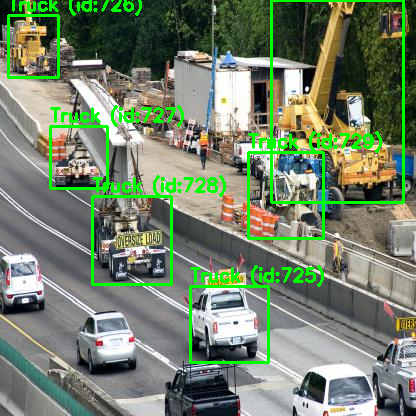

In [41]:
import json
import cv2
import os
from google.colab.patches import cv2_imshow

# -----------------------------
# 1) 경로 설정
# -----------------------------
json_path = "/content/object/train/_annotations.coco.json"
img_dir   = "/content/object/train/"

# 대상 이미지
target_image_file = "068868f40fb6dbec_jpg.rf.TuNx4cAV28rilGbgRwVh.jpg"
target_image_path = os.path.join(img_dir, target_image_file)

# -----------------------------
# 2) COCO JSON 로드
# -----------------------------
with open(json_path, "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

# 카테고리 id -> 이름 맵
cat_map = {c["id"]: c["name"] for c in categories}

# -----------------------------
# 3) file_name 으로 image_id 찾기
# -----------------------------
image_id = None
for img in images:
    if img["file_name"] == target_image_file:
        image_id = img["id"]
        break

if image_id is None:
    print("⚠ 해당 file_name을 JSON에서 찾지 못했습니다:", target_image_file)
    raise SystemExit

print("✔ image_id =", image_id)

# -----------------------------
# 4) 해당 이미지의 annotation 모두 찾기
# -----------------------------
target_annos = [a for a in annotations if a["image_id"] == image_id]

print("\n========================================")
print("✔ 해당 이미지의 Annotation (원본 그대로 출력)")
print("========================================\n")
for ann in target_annos:
    print(json.dumps(ann, indent=4))   # ← 원본 JSON 형태 그대로 출력

# -----------------------------
# 5) 이미지 불러와서 박스 그리기
# -----------------------------
img = cv2.imread(target_image_path)
if img is None:
    print("이미지를 불러올 수 없음:", target_image_path)
        # 이미지 없음
else:
    for ann in target_annos:
        x, y, w, h = ann["bbox"]
        x2 = int(x + w)
        y2 = int(y + h)

        # 박스 그리기
        cv2.rectangle(img, (int(x), int(y)), (x2, y2), (0,255,0), 2)

        # 클래스명 표시
        cls_name = cat_map.get(ann["category_id"], "unknown")
        cv2.putText(
            img,
            f"{cls_name} (id:{ann['id']})",
            (int(x), int(y)-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    print("\n✔ 박스 시각화 결과")
    cv2_imshow(img)


## 상단에서 area

-[50, 126, 57.5, 62]
- width × height = 57.5 × 62 = 3565 → 정확히 맞음

✔ 왜 필요한가?
segmentation 모델(Mask R-CNN 등)에서 활용/ 작은 객체와 큰 객체의 비율 확인

- iscrowd
  - iscrowd = 0 → 너가 알고 있는 일반적인 객체 (사람 1명, 강아지 1마리 등)
  - iscrowd = 1 → 수많은 객체가 한 덩어리로 뭉쳐 있는 영역 (crowd), instance 분리가 불가능

## [2] 데이터로더기

In [48]:
import os
import json
from collections import defaultdict

import cv2
import torch
from torch.utils.data import Dataset, DataLoader

class SSDCocoDataset(Dataset):
    def __init__(self, img_dir, json_path, img_size=None, transforms=None):
        """
        img_dir    : 이미지 폴더 (예: /content/object/train)
        json_path  : COCO 어노테이션 경로 (예: /content/object/train/_annotations.coco.json)
        img_size   : (W, H) 리사이즈 사이즈 (예: (300, 300)), None이면 원본 유지
        transforms : 추가 torchvision transforms (선택)
        """
        self.img_dir = img_dir
        self.json_path = json_path
        self.img_size = img_size
        self.transforms = transforms

        with open(json_path, "r") as f:
            coco = json.load(f)

        images = coco["images"]
        annotations = coco["annotations"]
        self.categories = coco["categories"]  # 필요하면 label → name 매핑용

        # image_id → image_info
        self.id_to_img = {img["id"]: img for img in images}

        # image_id → [anno, anno, ...]
        annos_by_image = defaultdict(list)
        for ann in annotations:
            annos_by_image[ann["image_id"]].append(ann)

        # 최종적으로 사용할 샘플 리스트 구성
        self.samples = []
        for image_id, img_info in self.id_to_img.items():
            file_name = img_info["file_name"]
            img_path = os.path.join(img_dir, file_name)
            if not os.path.exists(img_path):
                # 혹시 json에는 있는데 파일이 없으면 스킵
                continue

            img_annos = annos_by_image.get(image_id, [])

            boxes = []
            labels = []
            for ann in img_annos:
                x, y, w, h = ann["bbox"]  # COCO: x, y, w, h
                xmin = x
                ymin = y
                xmax = x + w
                ymax = y + h
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(ann["category_id"])

            self.samples.append({
                "image_id": image_id,
                "file_name": file_name,
                "boxes": boxes,       # [ [xmin,ymin,xmax,ymax], ... ]
                "labels": labels      # [c1,c2,...]
            })

        print(f"✔ SSDCocoDataset 준비 완료: 총 {len(self.samples)}개 이미지")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        file_name = sample["file_name"]
        image_id = sample["image_id"]
        boxes = sample["boxes"]
        labels = sample["labels"]

        img_path = os.path.join(self.img_dir, file_name)
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"이미지를 불러올 수 없습니다: {img_path}")

        # BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        orig_h, orig_w = img.shape[:2]

        # 리사이즈가 필요한 경우
        if self.img_size is not None:
            new_w, new_h = self.img_size
            img = cv2.resize(img, (new_w, new_h))
            scale_x = new_w / orig_w
            scale_y = new_h / orig_h

            # 박스도 같이 스케일 조정
            scaled_boxes = []
            for (xmin, ymin, xmax, ymax) in boxes:
                xmin = xmin * scale_x
                xmax = xmax * scale_x
                ymin = ymin * scale_y
                ymax = ymax * scale_y
                scaled_boxes.append([xmin, ymin, xmax, ymax])
            boxes = scaled_boxes

        # numpy → torch.Tensor, CHW형태
        img = img.astype("float32") / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1)  # HWC → CHW

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id])
        }

        if self.transforms is not None:
            # 만약 torchvision transforms를 쓰면, 이미지/박스 동시 변환용 커스텀 transform 필요
            img, target = self.transforms(img, target)

        return img, target


In [49]:
#------------------------------
# 데이터로더할 갯수가 다를때
#-------------------------------
def ssd_collate_fn(batch):
    images, targets = list(zip(*batch))  # 튜플 → 리스트
    return list(images), list(targets)

# -----------------------------
# 데이터셋 / 데이터로더 생성
# -----------------------------
img_dir = "/content/object/train"
json_path = "/content/object/train/_annotations.coco.json"

dataset = SSDCocoDataset(
    img_dir=img_dir,
    json_path=json_path,
    img_size=(300, 300)  # SSD300 기준, 아니면 None
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=ssd_collate_fn
)


✔ SSDCocoDataset 준비 완료: 총 878개 이미지


In [51]:
#-------------------------------------
# 배치한개 추출해서 확인
# ---------------------------
images, targets = next(iter(loader))

print(len(images), "개 이미지 로드됨")
print("첫 번째 이미지 shape:", images[0].shape)
print("첫 번째 이미지 boxes:", targets[0]["boxes"])
print("첫 번째 이미지 labels:", targets[0]["labels"])

4 개 이미지 로드됨
첫 번째 이미지 shape: torch.Size([3, 300, 300])
첫 번째 이미지 boxes: tensor([[120.4327,  64.9038, 242.3077, 165.8654]])
첫 번째 이미지 labels: tensor([1])


# [3] SSD에 맞는 데이터 로더기

In [53]:
import os
import json
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

class SimpleSSDDataset(Dataset):
    def __init__(self, img_dir, json_path, resize=(300, 300)):
        self.img_dir = img_dir
        self.json_path = json_path
        self.resize = resize

        # JSON 로드
        with open(json_path, "r") as f:
            coco = json.load(f)

        self.images = coco["images"]
        self.annotations = coco["annotations"]

        # image_id → annotation들
        self.annos_map = {}
        for ann in self.annotations:
            img_id = ann["image_id"]
            if img_id not in self.annos_map:
                self.annos_map[img_id] = []
            self.annos_map[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        file_name = img_info["file_name"]
        img_id = img_info["id"]

        img_path = os.path.join(self.img_dir, file_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype("float32")

        orig_h, orig_w = img.shape[:2]

        # 리사이즈 (300×300)
        img = cv2.resize(img, self.resize)
        img = img / 255.0
        img = torch.tensor(img).permute(2, 0, 1)  # HWC→CHW

        # Annotation 가져오기
        annos = self.annos_map.get(img_id, [])
        boxes = []
        labels = []

        for ann in annos:
            x, y, w, h = ann["bbox"]
            xmin = x
            ymin = y
            xmax = x + w
            ymax = y + h

            # 리사이즈 비율 적용
            scale_x = self.resize[0] / orig_w
            scale_y = self.resize[1] / orig_h

            xmin *= scale_x
            xmax *= scale_x
            ymin *= scale_y
            ymax *= scale_y

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann["category_id"])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return img, target

def ssd_collate(batch):
    imgs, targets = zip(*batch)
    return list(imgs), list(targets)

In [54]:
img_dir = "/content/object/train"
json_path = "/content/object/train/_annotations.coco.json"

dataset = SimpleSSDDataset(img_dir, json_path)
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=ssd_collate)

# [4] torchvision의 ssd모델로 사용

In [55]:
import torchvision

model = torchvision.models.detection.ssd300_vgg16(weights="DEFAULT")
model.train()

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:02<00:00, 59.1MB/s]


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [56]:
num_classes = 6   # 예: 5개 클래스 + background(SSD가 자동 포함)
model.head.classification_head.num_classes = num_classes

In [57]:
import torch

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


In [60]:
imgs, targets = next(iter(loader))


imgs = [img for img in imgs]
targets = [{k: v for k, v in t.items()} for t in targets]

model = model.cpu()  # Cpu 사용, GPU는  model.to("cuda")

loss_dict = model(imgs, targets)
loss = sum(loss_dict.values())

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("loss:", loss.item())


loss: 6.67527961730957


# [5] 추론


In [62]:
# 저장된 모델 로드 (예)

model.eval()
model.to(device)


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [64]:
import cv2
import torch
from google.colab.patches import cv2_imshow

def ssd_inference(model, img_path, label_map, score_threshold=0.3):
    model.eval()

    # 1. 이미지 읽기
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype("float32")

    orig_h, orig_w = img_rgb.shape[:2]

    # 2. SSD 입력 크기(300x300)로 리사이즈
    resized = cv2.resize(img_rgb, (300, 300)) / 255.0
    tensor = torch.tensor(resized).permute(2, 0, 1).unsqueeze(0)  # [1,3,300,300]

    tensor = tensor.to(device)
    model.to(device)

    # 3. 추론
    with torch.no_grad():
        outputs = model(tensor)[0]

    boxes = outputs["boxes"].cpu().numpy()
    labels = outputs["labels"].cpu().numpy()
    scores = outputs["scores"].cpu().numpy()

    # 4. 시각화
    for box, label, score in zip(boxes, labels, scores):
        if score < score_threshold:
            continue

        xmin, ymin, xmax, ymax = box
        # 300→원본 크기로 되돌리기
        xmin = int(xmin / 300 * orig_w)
        xmax = int(xmax / 300 * orig_w)
        ymin = int(ymin / 300 * orig_h)
        ymax = int(ymax / 300 * orig_h)

        # 박스 그리기
        cv2.rectangle(img,
                      (xmin, ymin),
                      (xmax, ymax),
                      (0,255,0),
                      2)

        # 라벨 텍스트
        cls_name = label_map.get(label, "unknown")
        cv2.putText(img,
                    f"{cls_name} {score:.2f}",
                    (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0,255,0), 2)

    cv2_imshow(img)


label_map = {}
for c in coco["categories"]:
    label_map[c["id"]] = c["name"]

label_map



{0: 'vehicles',
 1: 'Ambulance',
 2: 'Bus',
 3: 'Car',
 4: 'Motorcycle',
 5: 'Truck'}

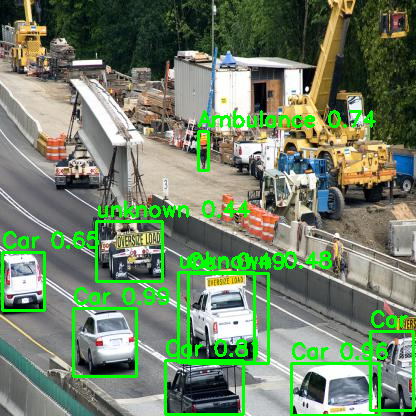

In [65]:
img_path = "/content/object/train/068868f40fb6dbec_jpg.rf.TuNx4cAV28rilGbgRwVh.jpg"

ssd_inference(model, img_path, label_map, score_threshold=0.4)


# [6] IOU 시각
✔ 예측 박스(녹색)
✔ 실제(GT) 박스(파란색)
✔ IoU 계산해서 출력
✔ 박스마다 IoU 값 표시

In [78]:
def calc_iou(boxA, boxB):
    # box: [xmin, ymin, xmax, ymax]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return interArea / (boxAArea + boxBArea - interArea + 1e-6)


In [79]:
#-------------------------------------------------
# GT가져오기
#-------------------------------------------------

def get_gt_boxes(json_data, target_file_name):
    # images 배열에서 id 찾기
    img_info = next(x for x in json_data["images"] if x["file_name"] == target_file_name)
    img_id = img_info["id"]

    # annotations에서 해당 image_id의 박스 모두 가져오기
    gt_annos = [a for a in json_data["annotations"] if a["image_id"] == img_id]

    # COCO → xmin,ymin,xmax,ymax 변환
    gt_boxes = []
    gt_labels = []
    for ann in gt_annos:
        x, y, w, h = ann["bbox"]
        gt_boxes.append([x, y, x + w, y + h])
        gt_labels.append(ann["category_id"])

    return gt_boxes, gt_labels


In [80]:
import cv2
import torch
from google.colab.patches import cv2_imshow

def visualize_prediction_vs_gt(model, img_path, json_data, label_map, score_threshold=0.3):
    model.eval()

    # ---------------------------
    # 1) 이미지 로드
    # ---------------------------
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype("float32")
    H, W = img.shape[:2]

    # ---------------------------
    # 2) GT (정답) 박스 로드
    # ---------------------------
    file_name = os.path.basename(img_path)
    gt_boxes, gt_labels = get_gt_boxes(json_data, file_name)

    # ---------------------------
    # 3) SSD 입력 준비
    # ---------------------------
    resized = cv2.resize(img_rgb, (300, 300)) / 255.0
    tensor = torch.tensor(resized).permute(2, 0, 1).unsqueeze(0).to(device)

    # ---------------------------
    # 4) 모델 추론
    # ---------------------------
    with torch.no_grad():
        out = model(tensor)[0]

    pred_boxes = out["boxes"].cpu().numpy()
    pred_labels = out["labels"].cpu().numpy()
    scores = out["scores"].cpu().numpy()

    # ---------------------------
    # 5) 박스 다시 원본 크기로 복원
    # ---------------------------
    # SSD 출력은 300x300 기준 → 원본으로 scaling
    scale_x = W / 300
    scale_y = H / 300

    pred_boxes = [[
        box[0] * scale_x,
        box[1] * scale_y,
        box[2] * scale_x,
        box[3] * scale_y
    ] for box in pred_boxes]

    # ---------------------------
    # 6) GT 박스 그리기 (파란색)
    # ---------------------------
    for box, label in zip(gt_boxes, gt_labels):
        xmin, ymin, xmax, ymax = map(int, box)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255,0,0), 2)
        cls_name = label_map.get(label, "gt")
        cv2.putText(img, f"GT:{cls_name}", (xmin, ymin-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    # ---------------------------
    # 7) 예측 박스 그리기 (녹색) + IoU 계산
    # ---------------------------
    for p_box, p_label, score in zip(pred_boxes, pred_labels, scores):
        if score < score_threshold:
            continue

        xmin, ymin, xmax, ymax = map(int, p_box)

        # GT와 IoU 가장 높은 것 계산
        best_iou = 0
        for g_box in gt_boxes:
            best_iou = max(best_iou, calc_iou(p_box, g_box))

        cls_name = label_map.get(p_label, "pred")

        # 예측 박스 (녹색)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0,255,0), 2)
        cv2.putText(img,
                    f"P:{cls_name} {score:.2f} IoU:{best_iou:.2f}",
                    (xmin, ymin - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0,255,0), 2)

    # ---------------------------
    # 8) 결과 시각화
    # ---------------------------
    cv2_imshow(img)


In [81]:
import json

json_path = "/content/object/train/_annotations.coco.json"

with open(json_path, "r") as f:
    coco_json = json.load(f)

label_map = {c["id"]: c["name"] for c in coco_json["categories"]}
label_map


{0: 'vehicles',
 1: 'Ambulance',
 2: 'Bus',
 3: 'Car',
 4: 'Motorcycle',
 5: 'Truck'}

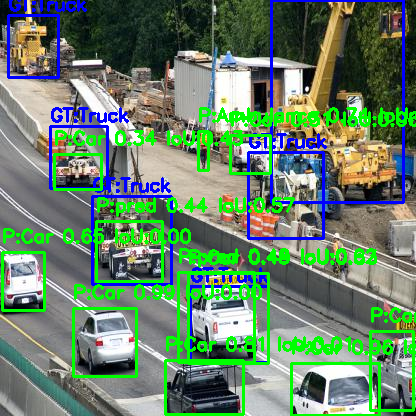

In [82]:
img_path = "/content/object/train/068868f40fb6dbec_jpg.rf.TuNx4cAV28rilGbgRwVh.jpg"

visualize_prediction_vs_gt(
    model,
    img_path,
    coco_json,     # 이제 정상 작동
    label_map,
    score_threshold=0.3
)
